In [78]:
import numpy as np
import matplotlib.pyplot as plt

from rsvd_correction.matrix_generators import SignalPlusNoise
from rsvd_correction.rsvd import _rsvd_sketch, rsvd
from rsvd_correction.free_probability import sketch_spectral_info

from experiments.config import N, K, P, SIGMA, SEED, NOISE_LEVEL
from experiments.benchmark import harmonic_signal

In [79]:
N_VIS = 500
K_VIS = 20
P_VIS = 30
SIGMA_VIS = harmonic_signal(K_VIS)

In [80]:
gen = SignalPlusNoise(sigma_signal=SIGMA_VIS, noise_level=NOISE_LEVEL)
A, sigma_true = gen(n=N_VIS, k=K_VIS, seed=SEED)

Y, m, n_cols, l, _, Sigma_rsvd, _ = _rsvd_sketch(A, K_VIS, P_VIS, SEED)
_, Sigma_corr, _                   = rsvd(A, K_VIS, p=P_VIS, seed=SEED, correction=True)

eigs_sketch, eigs_corr, c = sketch_spectral_info(Y, m, n_cols, l, K_VIS)

## Eigenvalue spectrum of $YY^\top$

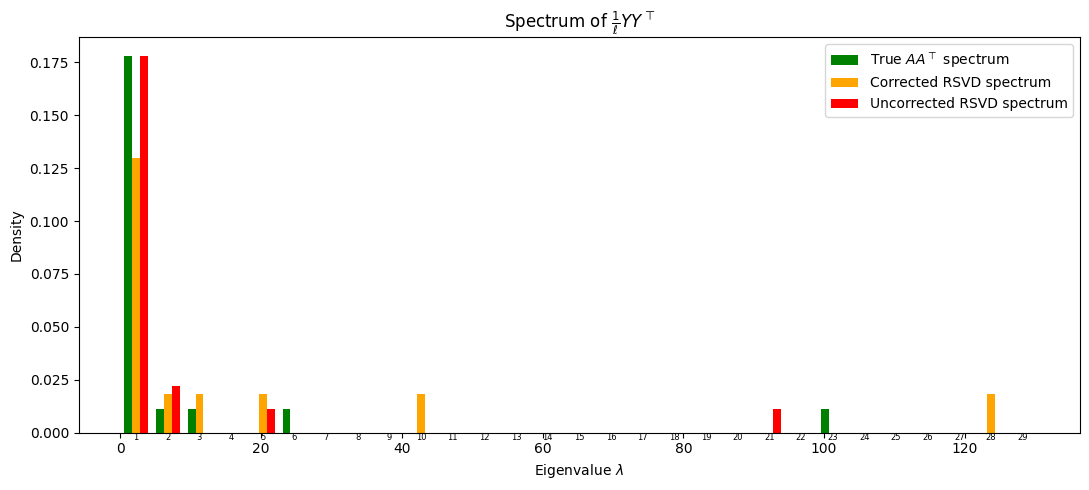

In [83]:
all_eigs = np.concatenate([sigma_true**2, eigs_corr, Sigma_rsvd**2])
bins  = np.linspace(0, all_eigs.max() * 1.05, 30)

counts_true, _ = np.histogram(sigma_true**2, bins=bins, density=True)
counts_corr, _ = np.histogram(eigs_corr,     bins=bins, density=True)
counts_rsvd, _ = np.histogram(Sigma_rsvd**2, bins=bins, density=True)

centres   = (bins[:-1] + bins[1:]) / 2
bin_width = bins[1] - bins[0]
bar_width = bin_width * 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(centres - bar_width, counts_true, width=bar_width, color="green",  label=r"True $AA^\top$ spectrum")
ax.bar(centres,             counts_corr, width=bar_width, color="orange", label="Corrected RSVD spectrum")
ax.bar(centres + bar_width, counts_rsvd, width=bar_width, color="red",    label="Uncorrected RSVD spectrum")

for i, centre in enumerate(centres, start=1):
    ax.text(centre, 0, str(i), ha="center", va="top", fontsize=6, color="black")

ax.set_xlabel(r"Eigenvalue $\lambda$")
ax.set_ylabel("Density")
ax.set_title(r"Spectrum of $\frac{1}{\ell}YY^\top$")
ax.legend()
plt.tight_layout()
plt.show()

## Singular value estimates vs. true

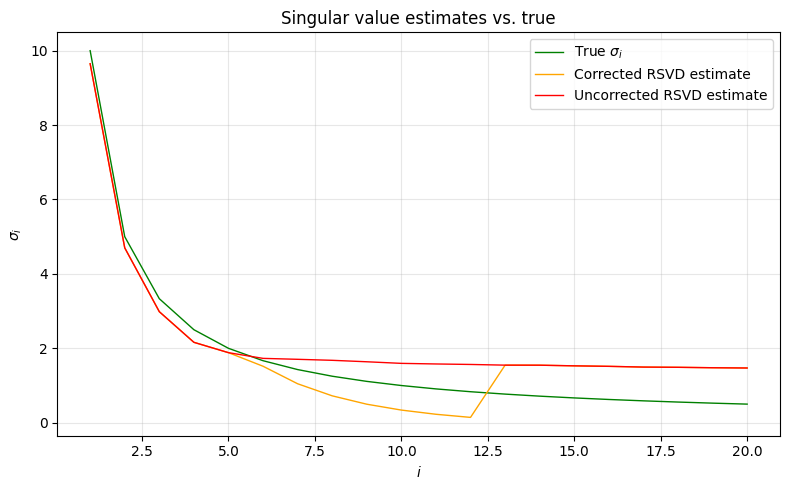

In [86]:
indices = np.arange(1, K_VIS + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(indices, sigma_true, color="green",  lw=1, label=r"True $\sigma_i$")
ax.plot(indices, Sigma_corr, color="orange", lw=1, label="Corrected RSVD estimate")
ax.plot(indices, Sigma_rsvd, color="red",    lw=1, label="Uncorrected RSVD estimate")
ax.set_xlabel(r"$i$")
ax.set_ylabel(r"$\sigma_i$")
ax.set_title("Singular value estimates vs. true")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()